In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
import re
import os
import numpy as np
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


# Parsing mot and sto files

In [2]:
def butter_lowpass_filter(data, cutoff, fs, order=6):
    nyq = 0.5 * fs
    wn = cutoff / nyq
    b, a = butter(order, wn, btype='low')
    return filtfilt(b, a, data, axis=0)

In [3]:
def dataframe(filePath, cutoff = 10, fs = 1000):
    header_index = 0
    with open(filePath, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if "endheader" in line:
            header_index = lines.index(line) + 1
            break
    df = pd.read_csv(filePath, sep='\t', skiprows=header_index)
    df.iloc[1:, 1:] = butter_lowpass_filter(df.iloc[1:,1:].astype(float).values, cutoff=cutoff, fs=fs)
    return df

# normalizing gait cycle

In [54]:
def normalize_gait_cycle(moment_curve):
    n = len(moment_curve)

    # original frame scale
    x_original = np.linspace(0, 100, n)

    # desired normalized gait %
    x_new = np.linspace(0, 100, 101)

    f = interp1d(x_original, moment_curve, kind='cubic')
    y_new = f(x_new)

    return x_new, y_new

filter grf file

In [4]:
def read_mot_with_header(path):
    with open(path, 'r') as f:
        lines = f.readlines()
    # find endheader index
    header_idx = next((i for i,l in enumerate(lines) if 'endheader' in l.lower()), None)
    if header_idx is None:
        raise ValueError("No 'endheader' found in file")
    header_lines = lines[:header_idx+1]      # include the 'endheader' line
    colnames_line = lines[header_idx+1].rstrip("\n")
    # load data (pandas will use the next line as column names)
    df = pd.read_csv(path, sep=r'\s+', engine='python', skiprows=header_idx+1)
    return header_lines, colnames_line, df

def detect_y_columns(df):
    cols = []
    for c in df.columns:
        low = c.lower()
        if re.search(r'(_vy$|_fy$|vy$|fy$)', low) or ('ground_force' in low and 'vy' in low):
            cols.append(c)
    return cols

def filter_file(in_path,
                        out_path=None,
                        cutoff=10.0,
                        order=6,
                        fs=None,
                        fs_fallback=1000.0,
                        # columns=["ground_force_1_px","ground_force_1_py","ground_force_1_pz"],
                        plot=False):
    """
    Read `in_path` (.mot/.sto), low-pass filter Y-GRF columns, and save to `out_path`
    preserving the original header and column-label line.
    If out_path is None, a new file `<inname>_filtered.mot` is created next to input.
    """
    header_lines, colnames_line, df = read_mot_with_header(in_path)

    # if columns is None:
    #     columns = detect_y_columns(df)
    # if not columns:
    #     raise ValueError("No Y-direction GRF columns detected. Provide `columns=` explicitly.")

    # estimate fs if not provided
    time_col = next((c for c in df.columns if c.lower() == 'time'), df.columns[0])
    time = df[time_col].values
    if fs is None:
        if len(time) >= 2:
            dt = np.mean(np.diff(time))
            fs = 1.0 / dt
        else:
            fs = fs_fallback

    # prepare numeric matrix and filter
    data_mat = df.iloc[:,1:].astype(float).values
    filtered_mat = butter_lowpass_filter(data_mat, cutoff=cutoff, fs=fs, order=order)

    # place filtered values back into dataframe copy
    df_filt = df.copy()
    df_filt.iloc[:, 1:] = filtered_mat

    # choose output path
    if out_path is None:
        base, ext = os.path.splitext(in_path)
        out_path = base + '_filtered' + (ext if ext else '.mot')

    # write header + original column label line + filtered data (no pandas header)
    with open(out_path, 'w', newline='\n') as f:
        f.writelines(header_lines)
        f.write(colnames_line + '\n')
    # append data without header (tab-separated for readability)
    df_filt.to_csv(out_path, sep='\t', index=False, header=False, float_format='%.6f', mode='a')
    # print(f"Saved filtered .mot to: {out_path}")

    if plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,6))
        for c in df.columns[1:]:  # skip time column
            plt.plot(time, df_filt[c].values, label=c)
        plt.xlabel('Time (s)')
        plt.ylabel('Force (N)')
        plt.title('Filtered GRF Y-direction (combined)')
        plt.legend(fontsize='small')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return df_filt, out_path

marking subjects as young middle and older

In [5]:
age_group = {"young" : [8,6,23,3,17,35],
            "middle" : [29,65,52,34,30,43],
            "older" : [53,55,45,54,42,56]}

## detecting initiation

using fy(t) - fy(baseline of ~ 1sec) > 2*SD(baseline)

In [57]:
def detect_intiation_force(mot_file):
    df = dataframe(mot_file)
    # frame_at_1s = (df["time"]-1.5).abs().idxmin()
    frame = (df["ground_force_1_vy"]>210).idxmax()
    fz_base = np.mean(df["ground_force_1_vy"][200:frame-50])
    print("fz_base",fz_base)
    baseline_std = np.std(df["ground_force_1_vy"][200:frame-50])
    print("baseline_std",baseline_std)

    mask = df["ground_force_1_vy"] - fz_base > 2*baseline_std
    initiation_frame = mask.idxmax()

    return initiation_frame

itiation frame using cop

In [7]:
#
def detect_intiation_cop(mot_file):
    df = filter_file(mot_file)[0]
    frame_at_1s = (df["time"]-1.0).abs().idxmin()
    fz_base = sum(df["ground_force_1_py"][:frame_at_1s])/frame_at_1s
    baseline_std = np.std(df["ground_force_1_py"][:frame_at_1s])

    mask = (df["ground_force_1_py"] - fz_base ).abs()> baseline_std
    initiation_frame = mask.idxmax()
    return initiation_frame

# detect end frame

In [8]:
# Detect heel strike and toe off events from vertical GRF
def detect_gait_end(grf_file, fs=1000, cutoff=20, threshold=20, min_width=15):
    # ==============================
    # USER INPUTS
    # ==============================
    # grf_file = '../donottouch/stw1.mot'   # your force plate file
    # fs = 1000                     # sampling frequency (Hz)
    # cutoff = 20                  # Butterworth cutoff frequency (Hz)
    # threshold = 20               # force threshold (N)
    # min_width = 15               # minimum width in samples

    # ==============================
    # READ OpenSim .sto FILE
    # ==============================
    with open(grf_file, 'r') as f:
        for i, line in enumerate(f):
            if 'endheader' in line.lower():
                header_line = i
                break

    data = pd.read_csv(
        grf_file,
        sep=r'\s+',
        skiprows=header_line + 1
    )

    time = data['time'].values
    vy_raw = data['ground_force_3_vy'].values  # vertical GRF

    # ==============================
    # BUTTERWORTH FILTER (zero-phase)
    # ==============================
    b, a = butter(
        N=4,
        Wn=cutoff / (fs / 2),
        btype='low'
    )

    vy_filt = filtfilt(b, a, vy_raw)

    # ==============================
    # GAIT EVENT DETECTION
    # ==============================
    above = vy_filt > threshold

    HS_idx = []
    TO_idx = []

    i = 0
    while i < len(above) - min_width:
        # Heel Strike: below → above threshold for >= min_width samples
        if not above[i] and all(above[i+1:i+1+min_width]):
            HS_idx.append(i + 1)
            i += min_width
            continue

        # Toe Off: above → below threshold for >= min_width samples
        if above[i] and all(~above[i+1:i+1+min_width]):
            TO_idx.append(i + 1)
            i += min_width
            continue

        i += 1

    HS_times = time[HS_idx]
    TO_times = time[TO_idx]
    # print(TO_idx[0]//5)
    return TO_idx[0]

    # ==============================
    PLOT
    #==============================
    plt.figure(figsize=(10, 5))

    plt.plot(time, vy_filt, label='Vertical GRF (filtered)', color='black')
    plt.axhline(threshold, linestyle='--', color='gray', label='20 N Threshold')

    plt.scatter(HS_times, vy_filt[HS_idx],
                color='green', label='Heel Strike', zorder=3)

    plt.scatter(TO_times, vy_filt[TO_idx],
                color='red', label='Toe Off', zorder=3)

    plt.xlabel('Time (s)')
    plt.ylabel('Vertical GRF (N)')
    plt.title('Gait Event Detection from Vertical GRF')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [9]:
from ezc3d import c3d
from scipy.signal import find_peaks, argrelmin, butter, filtfilt
import numpy as np


def align_axis(traj):
    """
    Find the dominant movement axis for a 3xN trajectory (X,Y,Z).
    Returns 0, 1, or 2.
    """
    diffs = traj[:, -1] - traj[:, 0]
    axis = np.argmax(np.abs(diffs))
    return axis


def absolute(x, axis):
    """
    Ensure motion along dominant axis is positive by reversing the time
    order if needed. x is 3xN.
    """
    if (x[axis][-1] - x[axis][0]) < 0:
        x[0] = list(reversed(x[0]))
        x[1] = list(reversed(x[1]))
        x[2] = list(reversed(x[2]))
    return x


def lowpass(signal, fs=200, cutoff=8, order=4):
    """
    Zero‑phase low‑pass Butterworth filter.
    fs: sampling rate (Hz)
    cutoff: cutoff frequency (Hz)
    """
    b, a = butter(order, cutoff / (fs / 2), btype='low')
    return filtfilt(b, a, signal)


def load_c3d_markers(c3d_path):
    """
    Load C3D file and return marker trajectories and labels.
    """
    c = c3d(c3d_path)
    markers = c['data']['points']          # (4, N_markers, N_frames)
    labels = c['parameters']['POINT']['LABELS']['value']
    xyz = markers[:3, :, :]                # (3, N_markers, N_frames)
    return xyz, labels


def compute_sacrum(xyz, labels):
    """
    Build pelvis reference trajectory as average of LASIS and RASIS.
    """
    rasis_idx = labels.index('RASIS')
    lasis_idx = labels.index('LASIS')

    trajectory_rasis = xyz[:, rasis_idx, :]
    trajectory_lasis = xyz[:, lasis_idx, :]

    trajectory_sacrum = (trajectory_lasis + trajectory_rasis) / 2.0
    return trajectory_sacrum


def extract_1d_marker(xyz, labels, name, axis, make_absolute=True):
    """
    Extract 1D trajectory of a marker along given axis, optionally applying
    absolute() to orient it consistently.
    """
    idx = labels.index(name)
    traj = xyz[:, idx, :]

    if make_absolute:
        traj = absolute(traj, axis)

    traj_1d = traj[axis]
    return traj_1d


def compute_relative_foot_signals(trajectory_sacrum_1d,
                                  trajectory_lfcc_1d,
                                  trajectory_rfcc_1d,
                                  trajectory_lfmt2_1d,
                                  trajectory_rfmt2_1d):
    """
    Compute pelvis-relative 1D signals: heel/toe (now LFCC/RFCC, LFMT2/RFMT2) minus sacrum.
    """
    lhs = trajectory_lfcc_1d - trajectory_sacrum_1d   # left heel vs sacrum (LFCC)
    rhs = trajectory_rfcc_1d - trajectory_sacrum_1d   # right heel vs sacrum (RFCC)
    lto = trajectory_lfmt2_1d - trajectory_sacrum_1d  # left toe vs sacrum (LFMT2)
    rto = trajectory_rfmt2_1d - trajectory_sacrum_1d  # right toe vs sacrum (RFMT2)
    return lhs, rhs, lto, rto


def detect_events(lhs, rhs, lto, rto, fs=200):
    """
    Coordinate-based gait event detection with filtering and constraints.
    - Heel strike: peaks in heel-sacro distance (lhs, rhs)
    - Toe off: minima in toe-sacro distance (lto, rto)
    """

    # 1) Low-pass filter the signals
    lhs_f = lowpass(lhs, fs=fs, cutoff=8)
    rhs_f = lowpass(rhs, fs=fs, cutoff=8)
    lto_f = lowpass(lto, fs=fs, cutoff=8)
    rto_f = lowpass(rto, fs=fs, cutoff=8)

    # 2) Peak/minimum detection parameters (tune as needed)
    min_step_frames = 180   # ~0.9 s at 200 Hz, adjust per dataset
    prominence = 30         # adjust based on signal amplitude

    left_hs_idx, _ = find_peaks(lhs_f,
                                distance=min_step_frames,
                                prominence=prominence)
    right_hs_idx, _ = find_peaks(rhs_f,
                                 distance=min_step_frames,
                                 prominence=prominence)

    left_to_idx = argrelmin(lto_f, order=40)[0][-1]
    right_to_idx = argrelmin(rto_f, order=40)[0][-1]

    return left_hs_idx[-1], right_hs_idx[-1], left_to_idx, right_to_idx


def main_hs(c3d_path,leg):
    # Path to your C3D file
    c3d_path = r"D:\student\MTech\Sakshi\STW\S01\ExpData\Mocap\stw2.c3d"

    fs_markers = 200  # Hz

    # Load data
    xyz, labels = load_c3d_markers(c3d_path)

    # Pelvis reference trajectory (3D) from LASIS/RASIS
    trajectory_sacrum = compute_sacrum(xyz, labels)

    # Determine dominant axis from pelvis and orient positively
    axis = align_axis(trajectory_sacrum)
    trajectory_sacrum = absolute(trajectory_sacrum, axis)
    trajectory_sacrum_1d = trajectory_sacrum[axis]

    # Foot markers along dominant axis (using LFCC/RFCC and LFMT2/RFMT2)
    trajectory_rfcc_1d = extract_1d_marker(xyz, labels, 'RFCC', axis, make_absolute=True)
    trajectory_rfmt2_1d = extract_1d_marker(xyz, labels, 'RFMT2', axis, make_absolute=True)
    trajectory_lfcc_1d = extract_1d_marker(xyz, labels, 'LFCC', axis, make_absolute=True)
    trajectory_lfmt2_1d = extract_1d_marker(xyz, labels, 'LFMT2', axis, make_absolute=True)

    # Pelvis-relative signals
    lhs, rhs, lto, rto = compute_relative_foot_signals(
        trajectory_sacrum_1d,
        trajectory_lfcc_1d,
        trajectory_rfcc_1d,
        trajectory_lfmt2_1d,
        trajectory_rfmt2_1d
    )

    # Detect gait events
    left_hs, right_hs, left_to, right_to = detect_events(lhs, rhs, lto, rto, fs=fs_markers)
    if leg.lower() == 'l':
        return (left_hs)
    else:
        return (right_hs)
    
    print("Dominant axis:", axis)
    print("Left heel strike indices:", left_hs)
    print("Right heel strike indices:", right_hs)
    print("Left toe off indices:", left_to)
    print("Right toe off indices:", right_to)


if __name__ == "__main__":
    c3d_file_path = r"D:\student\MTech\Sakshi\STW\S01\ExpData\Mocap\stw2.c3d"
    main_hs(c3d_file_path,leg = 'R')



# id plot

In [10]:
dataframe(r"d:\RESEARCH\STW_dataset\Extracted\S01\ID\results_ID\id_output_s01_stw1.sto")

,time,pelvis_tilt_moment,pelvis_list_moment,pelvis_rotation_moment,pelvis_tx_force,pelvis_ty_force,pelvis_tz_force,hip_flexion_r_moment,hip_adduction_r_moment,hip_rotation_r_moment,...,knee_angle_r_moment,knee_angle_r_beta_force,knee_angle_l_moment,knee_angle_l_beta_force,ankle_angle_r_moment,ankle_angle_l_moment,subtalar_angle_r_moment,subtalar_angle_l_moment,mtp_angle_r_moment,mtp_angle_l_moment
0,-0.000,-17.131789,0.067731,-0.911745,1.714448,627.908914,-0.604448,28.213132,-3.557606,0.158214,...,2.879336,-0.022554,4.807888,-0.022795,-0.001383,-3.448819,-1.077989,-0.662842,-0.027066,-0.026433
1,0.005,-13.752269,0.172019,0.226024,2.547043,631.338705,-2.450539,27.817203,-2.786074,0.338244,...,3.294247,-0.022540,2.053658,-0.022791,-0.269107,-0.615266,-0.791506,-1.333320,-0.027167,-0.026774
2,0.010,-13.825152,0.179543,0.258269,2.573192,631.308696,-2.633281,27.895362,-2.741563,0.322293,...,3.232702,-0.022541,2.125010,-0.022790,-0.217925,-0.671000,-0.772404,-1.333427,-0.027210,-0.026805
3,0.015,-13.896918,0.187281,0.289966,2.595977,631.277760,-2.811564,27.973827,-2.697583,0.306328,...,3.170875,-0.022542,2.196465,-0.022788,-0.166360,-0.727005,-0.753525,-1.333113,-0.027254,-0.026836
4,0.020,-13.967447,0.195273,0.321082,2.615296,631.245915,-2.985000,28.052481,-2.654197,0.290372,...,3.108858,-0.022542,2.267915,-0.022787,-0.114491,-0.783195,-0.734895,-1.332385,-0.027296,-0.026867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,5.600,-13.892573,28.991429,4.190391,-84.336323,342.547779,0.803768,5.698098,-18.240921,-3.126932,...,9.248938,-0.037455,3.364206,-0.038546,-63.606156,-1.978586,-2.604536,2.343385,-0.050291,-0.031691
1121,5.605,-13.878129,28.989786,4.190523,-84.347134,342.646662,0.796523,5.703695,-18.232548,-3.125429,...,9.240699,-0.037454,3.360550,-0.038547,-63.586485,-1.976876,-2.604167,2.343142,-0.050303,-0.031697
1122,5.610,-13.866408,28.988402,4.190621,-84.355800,342.727039,0.790578,5.708229,-18.225742,-3.124207,...,9.234012,-0.037453,3.357578,-0.038547,-63.570461,-1.975469,-2.603862,2.342939,-0.050313,-0.031701
1123,5.615,-13.857000,28.987250,4.190692,-84.362673,342.791663,0.785754,5.711863,-18.220271,-3.123226,...,9.228644,-0.037453,3.355188,-0.038548,-63.557551,-1.974323,-2.603612,2.342771,-0.050320,-0.031704


In [11]:
joint_l_moments = ["hip_flexion_l_moment", "hip_adduction_l_moment", "hip_rotation_l_moment",
                 "knee_angle_l_moment", 
                 "ankle_angle_l_moment"]
joint_r_moments = ["hip_flexion_r_moment", "hip_adduction_r_moment", "hip_rotation_r_moment",
                 "knee_angle_r_moment",
                    "ankle_angle_r_moment"]
joints = ["hip_flexion", "hip_adduction", "hip_rotation",
                "knee_angle", "ankle_angle"]

which leg to select for analysis by visualization first leg step will be considered.

In [12]:
young_leg = pd.read_csv(rf"young.csv")
middle_leg = pd.read_csv(rf"middle.csv")
older_leg = pd.read_csv(rf"older.csv")
leg = pd.concat([young_leg, middle_leg, older_leg])

fetching the data across all subjects and trial

In [13]:
def subject_info(subject):
    csv_file = r"D:\student\MTech\opensim_pipeline_batch_processing\Subject Details.csv"
    try:
        with open(csv_file, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                if row['Subject Number'] == f"S{subject:02d}":
                    subject_id = row['Subject Number']
                    mass = row['Weight (kg)']
                    height = row['Height (m)']
                    return subject_id, mass, height
    except FileNotFoundError:
        print(f"Error: CSV file '{csv_file}' not found")

In [66]:
def joint_moments_data(subjects):
    
    data_table = {} 
    moment = {}
    trials = {}   

    for subject in subjects:
        for trial in range(1,6):
            try:
                df = dataframe(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\ID\results_ID\id_output_s{subject:02d}_stw{trial}.sto")
                mass = subject_info(subject)[1]
                df.iloc[1:,1:] = df.iloc[1:,1:] / float(mass)
            except Exception as e:
                print(f"Error occurred while loading data for subject {subject}, trial {trial}: {e}")
                continue
            which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
            start = detect_intiation_force(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
            start = int(start)//5
            print(f"Subject {subject}, Trial {trial}, Leg {which_leg}, \nStart Frame: {start}")
            end = detect_gait_end(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
            end = int(end)//5
            print("end",end)
            # end = main_hs(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\stw{trial}.c3d",leg = which_leg)
            # print("end1",end)
            if which_leg == 'L':
                joint_moments = joint_l_moments
            else:
                joint_moments = joint_r_moments
            # print(joint_moments)
            for joint_moment in joint_moments:
                if which_leg == "L" and ("abduction" in joint_moment or "rotation" in joint_moment):
                    moment[joint_moment] = normalize_gait_cycle((df[joint_moment].values)[start:end])*-1
                else:
                    moment[joint_moment] = normalize_gait_cycle((df[joint_moment].values)[start:end])[1]
            trials[trial] = moment
            moment = {}
        data_table[subject] = trials
        trials = {}

    return data_table
    

In [67]:
young_force = (joint_moments_data(age_group["young"]))
middle_force = (joint_moments_data(age_group["middle"]))
older_force = (joint_moments_data(age_group["older"]))

fz_base 180.4291381236905
baseline_std 21.187384451406796
Subject 8, Trial 1, Leg R, 
Start Frame: 541
end 967
fz_base 182.221844316383
baseline_std 28.023888516346034
Subject 8, Trial 2, Leg R, 
Start Frame: 861
end 1246
fz_base 191.0251103846491
baseline_std 23.30037913333548
Subject 8, Trial 3, Leg R, 
Start Frame: 739
end 1142
fz_base 171.0917603442389
baseline_std 23.400196524045914
Subject 8, Trial 4, Leg R, 
Start Frame: 835
end 1207
fz_base 174.67586564812999
baseline_std 23.60594418032542
Subject 8, Trial 5, Leg R, 
Start Frame: 872
end 1279
fz_base 140.13335783951362
baseline_std 29.81037905684756
Subject 6, Trial 1, Leg L, 
Start Frame: 582
end 954
fz_base 135.79386963801912
baseline_std 35.42701586078028
Subject 6, Trial 2, Leg L, 
Start Frame: 635
end 1020
fz_base 132.70707851754483
baseline_std 40.44387137510909
Subject 6, Trial 3, Leg L, 
Start Frame: 458
end 844
fz_base 138.26352865397135
baseline_std 34.40310367052177
Subject 6, Trial 4, Leg L, 
Start Frame: 647
end 10

In [23]:
#plot grf
def plot_grf(subject,trial,filter="None"):
    if filter.lower() == "y":
        grf = dataframe(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
        plt.plot(grf['ground_force_2_vy'].iloc[:1500])
        plt.title("ground_force_2_vy")
        plt.show()
    else:
        grf = pd.read_csv(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot",sep = "\t", skiprows = 6)
        plt.plot(grf['ground_force_2_vy'].iloc[:1500])
        plt.Line2D()
        plt.title("ground_force_2_vy")
        plt.show()

actual Plot

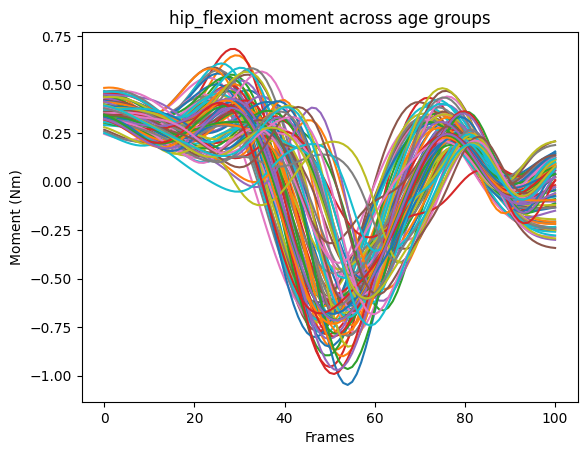

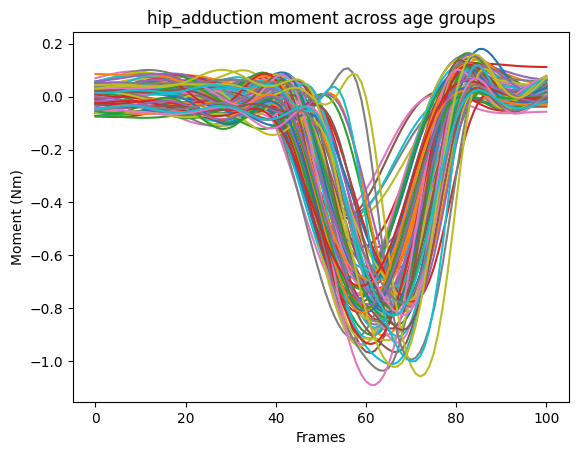

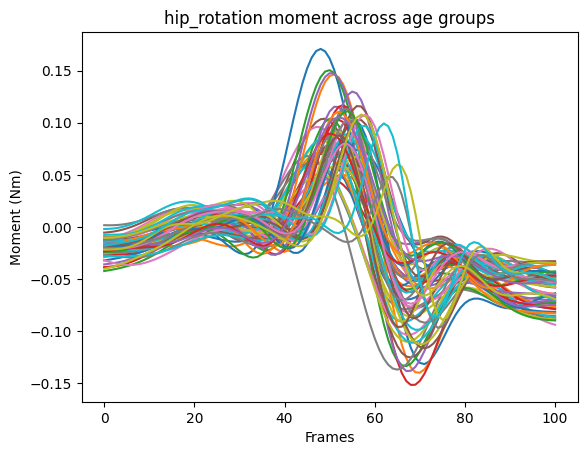

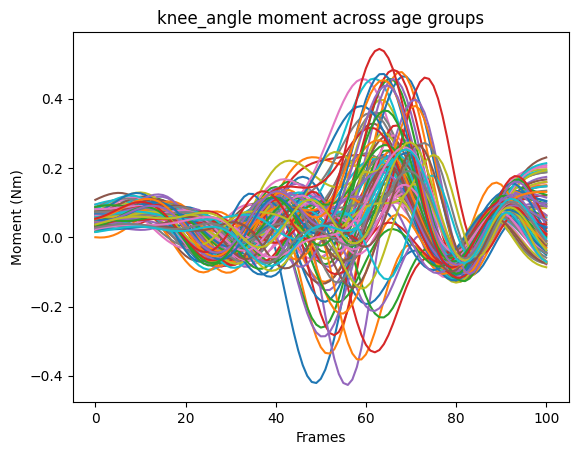

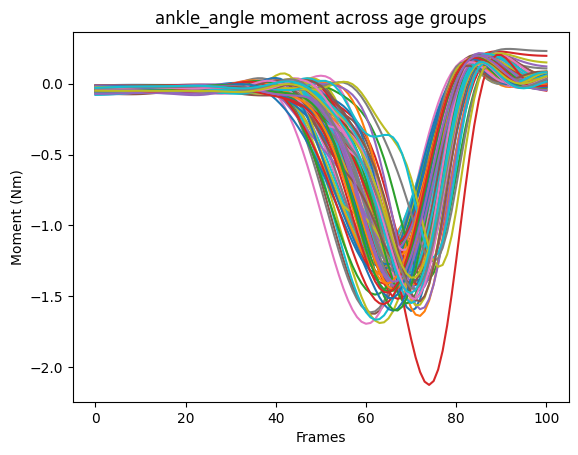

In [68]:
#plotting of force_moment data
# group = "young"
for joint_moment in joints:
    for group in age_group.keys():
        for subject in age_group[group]:
            for trial in range(1,6):
                which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
                
                if which_leg == 'L':
                    foot = "l"
                else:
                    foot = "r"
                data = globals()[f"{group}_force"][subject][trial][f"{joint_moment}_{foot}_moment"]
                
                plt.plot(data, label=f"Subject {subject} Trial {trial}")
                # plt.savefig(f"plots_of_all_individual\\{joint_moment}_{group}_subject{subject}_trial{trial}.png")
                # plt.clf()
    plt.title(f"{joint_moment} moment across age groups")
    plt.xlabel("Frames")
    plt.ylabel("Moment (Nm)")
    # plt.legend()
    plt.show()        

In [ ]:
#reading mot files
subject = 52
trial = 1
mot = dataframe(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
start = detect_intiation_force(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
print("start frame",start//5)
end = detect_gait_end(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
end1 = main_hs(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\stw{trial}.c3d",leg = leg[str(trial)].values[leg['subject'] == subject][0][0])
print(leg[str(trial)].values[leg['subject'] == subject][0][0])
print("end",end//5)
print("end1",end1)

frame 2531
fz_base 88.66247715033978
baseline_std 18.601301319722598
start frame 496
R
end 1006
end1 927


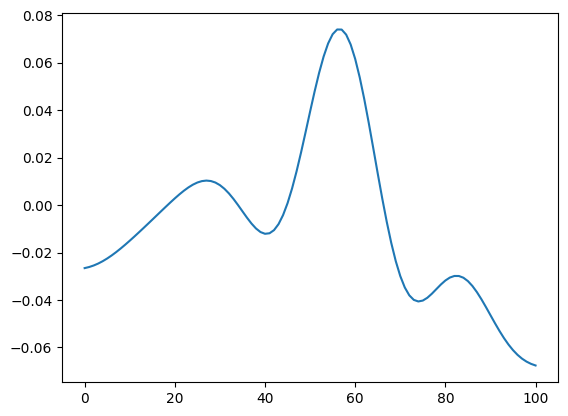

In [65]:
x, y = normalize_gait_cycle(young_force[8][1]['hip_rotation_r_moment'])
plt.plot(x,y)


[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100.]
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.

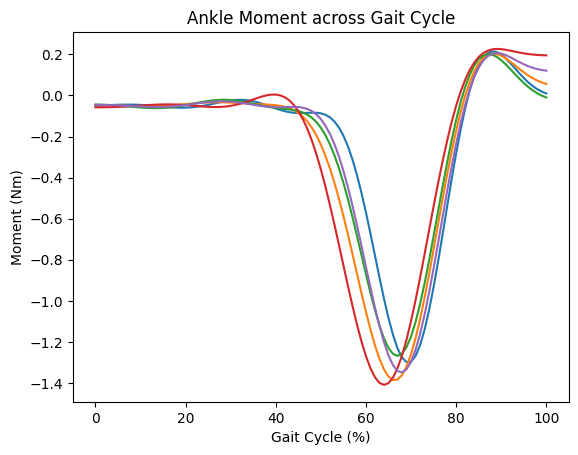

In [ ]:
plt.figure()

for trial in range(1,6):   # each trial = ankle moment array
    x, y = normalize_gait_cycle(middle_force[52][1]['ankle_angle_r_moment'])
    plt.plot(x,y)
    print(x)

plt.xlabel("Gait Cycle (%)")
plt.ylabel("Moment (Nm)")
plt.title("Ankle Moment across Gait Cycle")
plt.show()

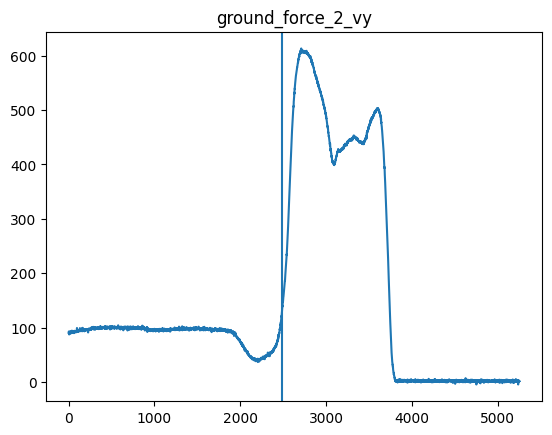

In [52]:
grf = pd.read_csv(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot",sep = "\t", skiprows = 6)
plt.plot(grf['ground_force_1_vy'].iloc[:])
plt.axvline(start)
plt.title("ground_force_2_vy")
plt.show()

# ik plot

In [ ]:
dataframe(r"d:\RESEARCH\STW_dataset\Extracted\S01\IK\results_stw\ik_output_stw1_S01.mot")

In [69]:
joint_angle_r = ["hip_flexion_r", "hip_adduction_r", "hip_rotation_r",
               "knee_angle_r", "ankle_angle_r"]
joint_angle_l = ["hip_flexion_l", "hip_adduction_l", "hip_rotation_l",
               "knee_angle_l", "ankle_angle_l"]

fetching the data across all subjects and trial

In [72]:
def joint_angles_data(subjects):
    
        data_table = {} 
        angle = {}
        trials = {}   
    
        for subject in subjects:
            for trial in range(1,6):
                try:
                     df = dataframe(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\IK\results_stw\ik_output_stw{trial}_S{subject:02d}.mot")
                except Exception as e:
                    print(f"Error occurred while loading data for subject {subject}, trial {trial}: {e}")
                    continue
                which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
                
                if which_leg == 'L':
                    joint_angles = joint_angle_l
                else:
                    joint_angles = joint_angle_r
                # print(joint_moments)
                start = detect_intiation_force(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
                start = int(start)//5
                print(f"Subject {subject}, Trial {trial}, Leg {which_leg}, \nStart Frame: {start}")
                end = detect_gait_end(rf"d:\RESEARCH\STW_dataset\Extracted\S{subject:02d}\S{subject:02d}\Mocap\grfResults\stw{trial}.mot")
                end = int(end)//5
                print("end",end)
                for joint_angle in joint_angles:
                    if which_leg == "L" and ("abduction" in joint_angle or "rotation" in joint_angle):
                        angle[joint_angle] = normalize_gait_cycle((df[joint_angle].values)[start:end])*-1
                    else:
                        angle[joint_angle] = normalize_gait_cycle((df[joint_angle].values)[start:end])[1]
                trials[trial] = angle
                angle = {}
            data_table[subject] = trials
            trials = {}

        return data_table
    

In [73]:
young_angle = (joint_angles_data(age_group["young"]))
middle_angle = (joint_angles_data(age_group["middle"]))
older_angle = (joint_angles_data(age_group["older"]))

fz_base 180.4291381236905
baseline_std 21.187384451406796
Subject 8, Trial 1, Leg R, 
Start Frame: 541
end 967
fz_base 182.221844316383
baseline_std 28.023888516346034
Subject 8, Trial 2, Leg R, 
Start Frame: 861
end 1246
fz_base 191.0251103846491
baseline_std 23.30037913333548
Subject 8, Trial 3, Leg R, 
Start Frame: 739
end 1142
fz_base 171.0917603442389
baseline_std 23.400196524045914
Subject 8, Trial 4, Leg R, 
Start Frame: 835
end 1207
fz_base 174.67586564812999
baseline_std 23.60594418032542
Subject 8, Trial 5, Leg R, 
Start Frame: 872
end 1279
fz_base 140.13335783951362
baseline_std 29.81037905684756
Subject 6, Trial 1, Leg L, 
Start Frame: 582
end 954
fz_base 135.79386963801912
baseline_std 35.42701586078028
Subject 6, Trial 2, Leg L, 
Start Frame: 635
end 1020
fz_base 132.70707851754483
baseline_std 40.44387137510909
Subject 6, Trial 3, Leg L, 
Start Frame: 458
end 844
fz_base 138.26352865397135
baseline_std 34.40310367052177
Subject 6, Trial 4, Leg L, 
Start Frame: 647
end 10

In [115]:
dataw = young_angle[6][3]

actual Plot

In [74]:
plt.plot(dataw["hip_flexion_l"])
plt.title("hip_flexion_l")

NameError: name 'dataw' is not defined

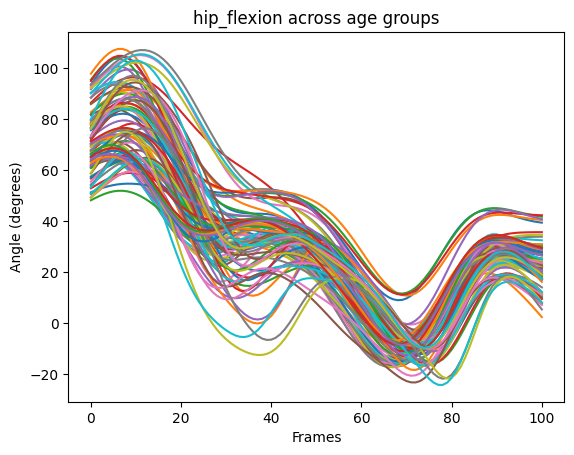

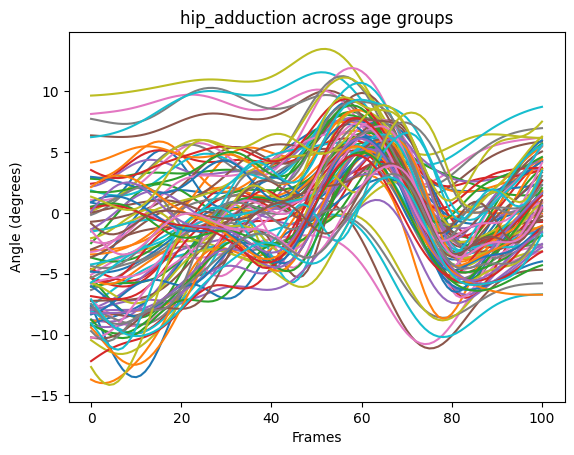

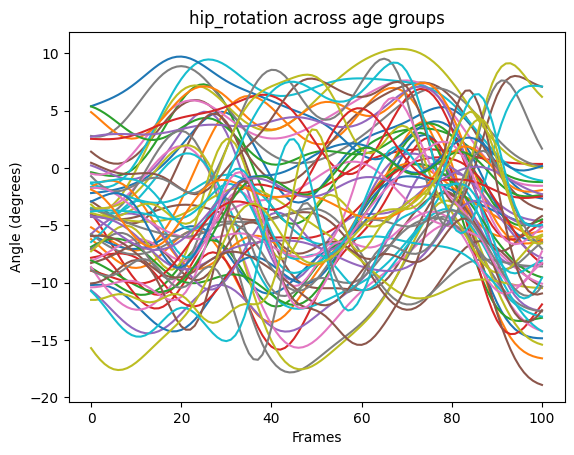

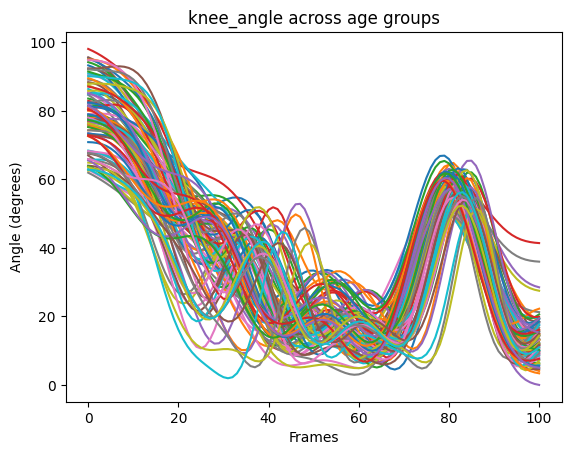

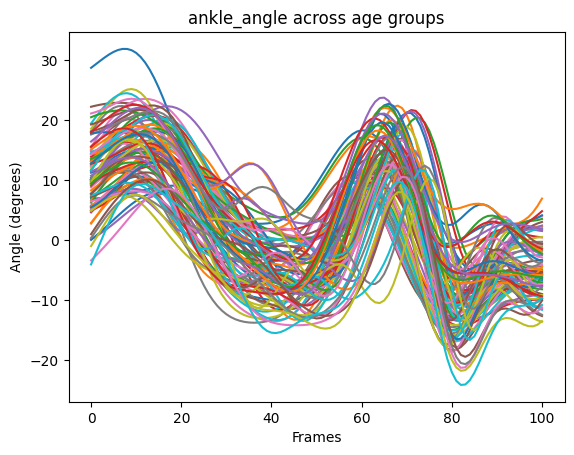

In [77]:
# group = "young"
for joint_angle in joints:
    for group in age_group.keys():
        for subject in age_group[group]:
            for trial in range(1,6):
                which_leg = leg[str(trial)].values[leg['subject'] == subject][0][0]
                
                if which_leg == 'L':
                    foot = "l"
                else:
                    foot = "r"
                data = globals()[f"{group}_angle"][subject][trial][f"{joint_angle}_{foot}"]
                plt.plot(data, label=f"Subject {subject} Trial {trial}")
    plt.title(f"{joint_angle} across age groups")
    plt.xlabel("Frames")
    plt.ylabel("Angle (degrees)")
    # plt.legend()
    plt.show()        